# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# bump dataset, bump encoding

In [ ]:
from a_datasets.bump.data import GaussianBumpDataset

# Dataset and DataLoader
dataset = GaussianBumpDataset(num_samples=1000, grid_size=28, scalar_encoding=False)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# show images
(data_x, data_y), target = next(iter(dataloader))

print(data_x.shape)
print(data_y.shape)
print(target.shape)

# bump encoding (see fig. 1a)
print("x position:", data_x[0])
print("y position:", data_y[0])

torch.Size([32, 28])
torch.Size([32, 28])
torch.Size([32, 1, 28, 28])
x position: tensor([1.5230e-08, 3.7267e-06, 3.3546e-04, 1.1109e-02, 1.3534e-01, 6.0653e-01,
        1.0000e+00, 6.0653e-01, 1.3534e-01, 1.1109e-02, 3.3546e-04, 3.7267e-06,
        1.5230e-08, 2.2897e-11, 1.2664e-14, 2.5768e-18, 1.9287e-22, 5.3111e-27,
        5.3802e-32, 2.0050e-37, 2.7465e-43, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00])
y position: tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.7465e-43,
        2.0050e-37, 5.3802e-32, 5.3111e-27, 1.9287e-22, 2.5768e-18, 1.2664e-14,
        2.2897e-11, 1.5230e-08, 3.7267e-06, 3.3546e-04, 1.1109e-02, 1.3534e-01,
        6.0653e-01, 1.0000e+00, 6.0653e-01, 1.3534e-01, 1.1109e-02, 3.3546e-04,
        3.7267e-06, 1.5230e-08, 2.2897e-11, 1.2664e-14])


5.5


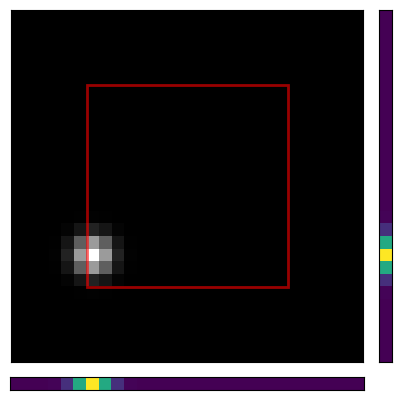

In [193]:
from matplotlib.gridspec import GridSpec

# scalar encoding
dataset = GaussianBumpDataset(
    num_samples=1000, grid_size=28, scalar_encoding=False, holdout_center=False, only_sample_holdout=True
)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
(data_x, data_y), target = next(iter(dataloader))

# plot
fig = plt.figure(figsize=(5, 5))
gs = GridSpec(2, 2, width_ratios=[15, 1], height_ratios=[15, 1], wspace=0.05, hspace=0.05)

# Main image
ax_main = fig.add_subplot(gs[0, 0])
ax_main.imshow(target[0].numpy().reshape(28, 28), cmap="gray")
ax_main.set_xticks([])
ax_main.set_yticks([])

# Bottom plot (x position indicator)
ax_top = fig.add_subplot(gs[1, 0], sharex=ax_main)
x_vals = np.linspace(0, 27, 28)
ax_top.imshow(data_x[0].unsqueeze(0).numpy())
ax_top.set_xlim(-0.5, 27.5)
ax_top.set_yticks([])

# Right plot (y position indicator)
ax_right = fig.add_subplot(gs[0, 1], sharey=ax_main)
ax_right.imshow(data_y[0].unsqueeze(1).numpy())
ax_right.set_ylim(27.5, -0.5)  # Inverted to match image coordinates
ax_right.set_xticks([])

# plot the holdout region
min_x_coord = min_y_coord = int(28 * 0.2) + 1 - 0.5
print(min_x_coord)
length_x = length_y = int(28 * 0.6)
ax_main.add_patch(
    plt.Rectangle((min_x_coord, min_y_coord), length_x, length_y, linewidth=2, edgecolor="red", facecolor="none", alpha=0.6)
)

# Hide the corner
ax_corner = fig.add_subplot(gs[1, 1])
ax_corner.axis("off")

plt.show()

## scalar encoding

5.5


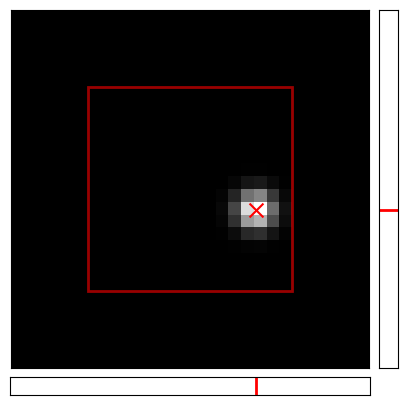

In [195]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# scalar encoding
dataset = GaussianBumpDataset(
    num_samples=1000, grid_size=28, seed=43, scalar_encoding=True, holdout_center=False, only_sample_holdout=True
)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

(data_x, data_y), target = next(iter(dataloader))

fig = plt.figure(figsize=(5, 5))
gs = GridSpec(2, 2, width_ratios=[20, 1], height_ratios=[20, 1], wspace=0.05, hspace=0.05)

# Main image
ax_main = fig.add_subplot(gs[0, 0])
ax_main.imshow(target[0].numpy().reshape(28, 28), cmap="gray")
ax_main.scatter(data_x[0], data_y[0], s=100, c="red", marker="x")
ax_main.set_xticks([])
ax_main.set_yticks([])

# Bottom plot (x position indicator)
ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax_main)
ax_bottom.axvline(data_x[0], color="red", lw=2)
ax_bottom.set_xlim(-0.5, 27.5)
ax_bottom.set_yticks([])

# Right plot (y position indicator)
ax_right = fig.add_subplot(gs[0, 1], sharey=ax_main)
ax_right.axhline(data_y[0], color="red", lw=2)
ax_right.set_ylim(27.5, -0.5)  # Inverted to match image coordinates
ax_right.set_xticks([])

# plot the holdout region
min_x_coord = min_y_coord = int(28 * 0.2) + 1 - 0.5
print(min_x_coord)
length_x = length_y = int(28 * 0.6)
ax_main.add_patch(
    plt.Rectangle((min_x_coord, min_y_coord), length_x, length_y, linewidth=2, edgecolor="red", facecolor="none", alpha=0.6)
)


# Hide the corner
ax_corner = fig.add_subplot(gs[1, 1])
ax_corner.axis("off")

plt.show()

[(0.0, 28.0), (0.0, 28.0)]

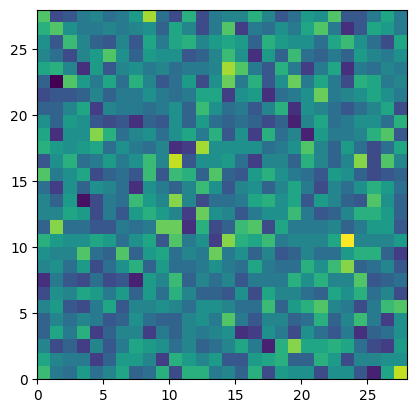

In [196]:
# now I want to see the distribution of all x and y values
dataset = GaussianBumpDataset(num_samples=10000, grid_size=28, seed=43, scalar_encoding=True, holdout_center=False, only_sample_holdout=False)
x, y = np.array(dataset.data_x), np.array(dataset.data_y)

fig, ax = plt.subplots(1, 1)
H, xedges, yedges = np.histogram2d(x, y, 28)
H = H.T
ax.imshow(H, interpolation='nearest', origin='lower',
        # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
        extent=[0, 28, 0, 28])
ax.set(xlim=[0, 28], ylim=[0, 28])

6.014360631700267 21.99480959644636


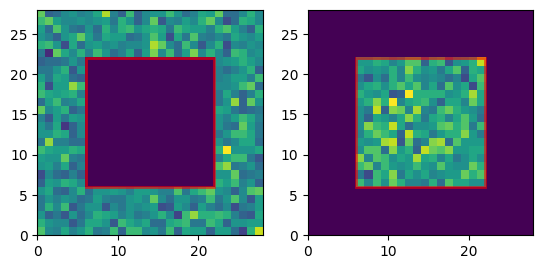

In [197]:
# now I want to see the distribution of all x and y values
dataset = GaussianBumpDataset(num_samples=10000, grid_size=28, seed=43, scalar_encoding=True, holdout_center=True, only_sample_holdout=False)
x, y = np.array(dataset.data_x), np.array(dataset.data_y)

fig, ax = plt.subplots(1, 2)
H, xedges, yedges = np.histogram2d(x, y, 28)
H = H.T
ax[0].imshow(H, interpolation='nearest', origin='lower',
        # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
        extent=[0, 28, 0, 28])
ax[0].set(xlim=[0, 28], ylim=[0, 28])


# now I want to see the distribution of all x and y values
dataset = GaussianBumpDataset(num_samples=10000, grid_size=28, seed=43, scalar_encoding=True, holdout_center=False, only_sample_holdout=True)
x, y = np.array(dataset.data_x), np.array(dataset.data_y)
print(min(dataset.data_x), max(dataset.data_x))

H, xedges, yedges = np.histogram2d(x, y, 16)
H = H.T
H_full = np.zeros((28, 28))
x_start = int(np.floor(xedges[0]))
x_end = int(np.ceil(xedges[-1]))
y_start = int(np.floor(yedges[0]))
y_end = int(np.ceil(yedges[-1]))
H_full[y_start:y_start+16, x_start:x_start+16] = H
ax[1].imshow(H_full, interpolation='nearest', origin='lower',
        extent=[0, 28, 0, 28])
ax[1].set(xlim=[0, 28], ylim=[0, 28])

min_x_coord = min_y_coord = int(28 * 0.2) + 1
length_x = length_y = int(28 * 0.6)
ax[0].add_patch(plt.Rectangle((min_x_coord, min_y_coord), length_x, length_y, linewidth=2, edgecolor="red", facecolor="none", alpha=0.6))
ax[1].add_patch(plt.Rectangle((min_x_coord, min_y_coord), length_x, length_y, linewidth=2, edgecolor="red", facecolor="none", alpha=0.6))

In [ ]:
# now what? I have this dataset, but I need to train my model on it. Let's start by training a simple model on the full dataset and see how well it does. 
# then test the model on the OOD stuff

# then train the model on the hierarchical dataset. 

# also I need to read the diffusion compositionality paper. in what sense does it mean that it doesn't interpolate well? 

In [10]:
# load data from the load_dataset function
from a_datasets.bump.data import load_bump_data

cpu_tensor, (x, y) = load_bump_data(holdout_center=True)
print(cpu_tensor.shape)

torch.Size([6735, 1, 28, 28])


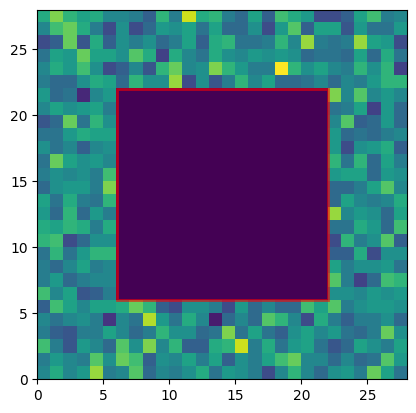

In [11]:
# now I want to see the distribution of all x and y values
fig, ax = plt.subplots(1, 1)
H, xedges, yedges = np.histogram2d(x, y, 28)
H = H.T

ax.imshow(H, interpolation='nearest', origin='lower',
        extent=[0, 28, 0, 28])
ax.set(xlim=[0, 28], ylim=[0, 28])

min_x_coord = min_y_coord = int(28 * 0.2) + 1
length_x = length_y = int(28 * 0.6)
ax.add_patch(plt.Rectangle((min_x_coord, min_y_coord), length_x, length_y, linewidth=2, edgecolor="red", facecolor="none", alpha=0.6))

# model

In [2]:
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.configs.sami_config import SAMI_Manual_dSprites_Training_Config

config = SAMI_Manual_dSprites_Training_Config()
model = SAMI_Lightning(config=config)

sami = model.model

test_x = torch.randn(1, 1, 64, 64)

sami(test_x)

/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([1, 1, 64, 64])
torch.Size([1])


(tensor([[[[ 0.0480, -0.5249,  0.3783,  ..., -0.3370, -2.1277, -0.5708],
           [ 0.2182,  0.2696, -0.6088,  ..., -1.5164,  0.3439, -1.0074],
           [ 0.5286,  0.9350,  0.3332,  ...,  1.6355, -0.0574,  0.2506],
           ...,
           [ 1.2124,  0.0227, -1.2666,  ...,  0.0886,  0.8756,  1.4064],
           [ 0.1529,  0.8513, -1.6003,  ..., -0.1577,  0.7452, -0.7921],
           [ 0.9876,  0.8716,  1.5276,  ..., -0.5276, -0.3092, -2.4515]]]],
        grad_fn=<SubBackward0>),
 tensor([[[[ 5.5021e-06,  6.0318e-05,  1.2954e-04,  ..., -1.2574e-06,
             4.9839e-05,  1.8212e-04],
           [-2.7572e-05, -5.5869e-05, -2.1935e-04,  ..., -1.1654e-04,
             7.6523e-05,  1.8513e-05],
           [-1.7038e-04,  6.7794e-05, -4.0309e-04,  ..., -2.9635e-04,
            -1.7701e-04, -2.4443e-04],
           ...,
           [ 7.0921e-05, -1.2618e-04,  6.2804e-04,  ...,  1.8768e-04,
             4.1757e-04, -3.6411e-04],
           [ 1.4912e-04,  4.3710e-04, -3.2622e-04,  ..., -

In [13]:
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.configs.sami_config import SAMI_Bump_Training_Config

config = SAMI_Bump_Training_Config()
model = SAMI_Lightning(config=config)
sami = model.model

test_x = torch.randn(1, 1, 28, 28)

target, pred = sami(test_x)
print(target.shape)

# uncond_velocity_estimate = self.denoiser(noisy_x, t_tensor)

torch.Size([1, 1, 28, 28])
torch.Size([1])
torch.Size([1, 1, 28, 28])


In [22]:
test_x = torch.randn(1, 1, 28, 28)

sami(test_x)

torch.Size([1, 1, 28, 28])
torch.Size([1])


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 6 but got size 7 for tensor number 1 in the list.

# test model on full bump dataset
no OOD test yet

In [ ]:
sami_lightning = 